In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.spatial.transform import Rotation as R
import numpy as np
from pathlib import Path
import json
import imageio
import matplotlib.pyplot as plt
import trimesh
from skimage import measure

In [ ]:
!pip install scikit-image trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 25.9 MB/s eta 0:00:00


In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d nguyenhung1903/nerf-synthetic-dataset -p /content/data
!unzip -q /content/data/nerf-synthetic-dataset.zip -d /content/data

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/nguyenhung1903/nerf-synthetic-dataset
License(s): unknown
100% 1.18G/1.18G [00:30<00:00, 40.9MB/s]



In [ ]:
!find /content/data -maxdepth 4 -type f | grep transforms_train.json | head

/content/data/nerf_synthetic/lego/transforms_train.json
/content/data/nerf_synthetic/chair/transforms_train.json
/content/data/nerf_synthetic/hotdog/transforms_train.json
/content/data/nerf_synthetic/materials/transforms_train.json
/content/data/nerf_synthetic/mic/transforms_train.json
/content/data/nerf_synthetic/ship/transforms_train.json
/content/data/nerf_synthetic/ficus/transforms_train.json
/content/data/nerf_synthetic/drums/transforms_train.json


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class HashTable(nn.Module):
  def __init__(self, resolution, table_size, feature_dimension):
    super().__init__()

    self.hashTable = nn.Parameter(torch.randn(table_size, feature_dimension))
    self.resolution = resolution
    self.table_size = table_size
    self.feature_dimension = feature_dimension

  def hash_function(self, x, y, z):
    x_int = x.to(torch.int32)
    y_int = y.to(torch.int32)
    z_int = z.to(torch.int32)
    return ((x_int * 73856093) ^ (y_int * 19349663) ^ (z_int * 83492791)) % self.table_size


  def forward(self, point):

    scaled = point * self.resolution
    floored = torch.floor(scaled)
    top_right = floored + 1
    x0, y0, z0 = floored[:, 0], floored[:, 1], floored[:, 2]
    x1, y1, z1 = top_right[:, 0], top_right[:, 1], top_right[:, 2]

    #hash 8 corner points
    h000 = self.hash_function(x0, y0, z0)
    h001 = self.hash_function(x0, y0, z1)
    h010 = self.hash_function(x0, y1, z0)
    h011 = self.hash_function(x0, y1, z1)
    h100 = self.hash_function(x1, y0, z0)
    h101 = self.hash_function(x1, y0, z1)
    h110 = self.hash_function(x1, y1, z0)
    h111 = self.hash_function(x1, y1, z1)

    #lookup hashed points in table -> 8 feature vectors
    t000 = self.hashTable[h000]
    t001 = self.hashTable[h001]
    t010 = self.hashTable[h010]
    t011 = self.hashTable[h011]
    t100 = self.hashTable[h100]
    t101 = self.hashTable[h101]
    t110 = self.hashTable[h110]
    t111 = self.hashTable[h111]

    inside_point = scaled - floored
    x_weight = inside_point[:, 0:1]
    y_weight = inside_point[:, 1:2]
    z_weight = inside_point[:, 2:3]

    #interpolate across x
    c00 = t000 * (1 - x_weight) + t100 * x_weight
    c10 = t010 * (1 - x_weight) + t110 * x_weight
    c01 = t001 * (1 - x_weight) + t101 * x_weight
    c11 = t011 * (1 - x_weight) + t111 * x_weight

    #interpolate across y
    c0 = c00 * (1 - y_weight) + c10 * y_weight
    c1 = c01 * (1 - y_weight) + c11 * y_weight

    #interpolate across z
    c = c0 * (1 - z_weight) + c1 * z_weight

    return c

In [ ]:
class MultiLevelHash(nn.Module):
  def __init__(self, resolutions, feature_dimension, table_size):
    super().__init__()
    self.tables = nn.ModuleList([HashTable(resolutions[i], table_size, feature_dimension) for i in range(len(resolutions))])

  def forward(self, x):
    res = [table(x) for table in self.tables]
    return torch.cat(res, dim = -1)

In [ ]:
class MLP(nn.Module):
  def __init__(self, hash_dim, output_dim):
    super().__init__()
    self.net = nn.Sequential(nn.Linear(hash_dim, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, output_dim))

  def forward(self, x):
    return self.net(x)

In [ ]:
class NeRF(nn.Module):
  def __init__(self,feature_dimension, output_dim, resolutions, table_size):
    super().__init__()
    self.hash_table = MultiLevelHash(resolutions, feature_dimension, table_size)
    self.mlp = MLP(len(resolutions) * feature_dimension, output_dim)


  def forward(self, x):
    features = self.hash_table(x)
    out = self.mlp(features)
    return out

In [ ]:
def get_ray(H, W, c2w, focal):
  i, j = torch.meshgrid(torch.arange(W), torch.arange(H), indexing="xy")
  dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], dim=-1)
  dirs = dirs.to(c2w.device)
  rays_d = dirs @ c2w[:3, :3].T
  rays_o = c2w[:3, 3].expand(rays_d.shape)
  return rays_o, rays_d




In [ ]:
def sample_points_stratified(rays_o, rays_d, near=2.0, far=6.0, num_samples=128):
    device = rays_o.device
    B = rays_o.shape[0]

    # bin edges: [S+1]
    t_edges = torch.linspace(near, far, num_samples + 1, device=device)

    # lower/upper edge of each bin: [S]
    lower = t_edges[:-1]
    upper = t_edges[1:]

    # random number inside each bin: [B, S]
    u = torch.rand(B, num_samples, device=device)

    # one random t value per bin
    t_vals = lower[None, :] + u * (upper - lower)[None, :]

    # convert t values to 3D points
    points = rays_o[:, None, :] + t_vals[:, :, None] * rays_d[:, None, :]

    return points, t_vals

In [ ]:
def sample_points_uniform(rays_o, rays_d, near=2.0, far=6.0, num_samples=128):
    device = rays_o.device
    t_vals = torch.linspace(near, far, num_samples, device=device)
    t_vals = t_vals.expand(rays_o.shape[0], num_samples)
    points = rays_o[:, None, :] + t_vals[:, :, None] * rays_d[:, None, :]
    return points, t_vals

In [ ]:
def volume_renderer(colors, densities, t_points):
  # Expected shapes:
  # colors: [B, S, 3]
  # densities: [B, S]
  # t_points: [B, S]

  device = t_points.device
  B, S = t_points.shape

  # Calculate differences between consecutive t_points for each ray
  time_differences = t_points[:, 1:] - t_points[:, :-1]

  # Create a tensor for the last difference, expanded for the batch dimension
  last_difference_scalar = torch.exp(torch.tensor(10.0, device=device))
  last_difference_tensor = last_difference_scalar.unsqueeze(0).expand(B, 1) # Shape [B, 1]

  # Concatenate time_differences and last_difference_tensor along the second dimension (S)
  differences = torch.cat((time_differences, last_difference_tensor), dim=1)

  # Calculate alphas: [B, S]
  alphas = 1 - torch.exp(-differences * densities)

  # Calculate transmittence
  ones_tensor = torch.ones(B, 1, device=device) # Shape [B, 1]
  transmittence_components = torch.cat((ones_tensor, 1 - alphas), dim=1) # Shape [B, S+1]
  transmittence = torch.cumprod(transmittence_components, dim=1)[:, :-1] # Shape [B, S]

  # Calculate weights: [B, S]
  weights = transmittence * alphas

  # Calculate final color by weighted sum of colors
  # weights is [B, S], colors is [B, S, 3]
  # Reshape weights to [B, S, 1] for broadcasting
  color = torch.sum(weights[:, :, None] * colors, dim=1) # Sum over S dimension, result [B, 3]

  return color, weights



In [ ]:
def load_blender_split(base_dir, split="train", downscale=2):
    base_dir = Path(base_dir)

    with open(base_dir / f"transforms_{split}.json", "r") as f:
        meta = json.load(f)

    imgs = []
    poses = []

    for frame in meta["frames"]:
        img_path = base_dir / (frame["file_path"] + ".png")
        img = imageio.imread(img_path).astype(np.float32) / 255.0

        img = img[::downscale, ::downscale, :]

        rgb = img[..., :3]
        alpha = img[..., 3:4]
        img = rgb * alpha + (1.0 - alpha)

        imgs.append(img)
        poses.append(np.array(frame["transform_matrix"], dtype=np.float32))

    imgs = torch.tensor(np.stack(imgs), dtype=torch.float32)
    poses = torch.tensor(np.stack(poses), dtype=torch.float32)

    H, W = imgs.shape[1:3]
    camera_angle_x = meta["camera_angle_x"]
    focal = 0.5 * W / np.tan(0.5 * camera_angle_x)

    return imgs, poses, H, W, focal

In [ ]:
num_steps = 10000
batch = 1024
num_samples = 128

imgs, poses, H, W, focal = load_blender_split("/content/data/nerf_synthetic/lego")
imgs = imgs.to(device)
poses = poses.to(device)
model = NeRF(feature_dimension=2, output_dim=4, resolutions=[2,4,8,16,32,64,128,256,512,1024], table_size=2**15).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 2e-3)
psnr_vals = []

total_loss = 0.0
for step in range(num_steps):
  optimizer.zero_grad()
  #sample random image/pose
  random_idx = torch.randint(high = imgs.shape[0], size = (1,)).item()
  img = imgs[random_idx]
  pose = poses[random_idx]

  #get rays for this image/pose
  ray_o, ray_d = get_ray(img.shape[0], img.shape[1], pose, focal)

  #randomly sample batch number of rays to train with
  ray_o_reshaped = ray_o.reshape(-1, 3)
  ray_d_reshaped = ray_d.reshape(-1, 3)
  img_reshaped = img.reshape(-1, 3)

  idx = torch.randint(
        0,
        ray_o_reshaped.shape[0],
        (batch,),
        device=device)

  batch_rays_o = ray_o_reshaped[idx]      # [B, 3]
  batch_rays_d = ray_d_reshaped[idx]      # [B, 3]
  target_rgb = img_reshaped[idx]        # [B, 3]

  points, t_vals = sample_points_stratified(batch_rays_o, batch_rays_d, near=2.0, far=6.0, num_samples=num_samples)

  B, S, _ = points.shape
  flattened_points = points.reshape(B * S, 3)

  scene_bound = 4.0
  flattened_points = (flattened_points + scene_bound) / (2 * scene_bound)
  flattened_points = flattened_points.clamp(0.0, 1.0)

  out = model(flattened_points)
  rgb_val = out[..., :3]
  density = out[..., 3]

  rgb_normalized = torch.sigmoid(rgb_val) # Shape: [B*S, 3]
  density_normalized = F.softplus(density)# Shape: [B*S]

  # Reshape for volume_renderer
  rgb_normalized = rgb_normalized.reshape(batch, num_samples, 3)
  density_normalized = density_normalized.reshape(batch, num_samples)

  color, weights = volume_renderer(rgb_normalized, density_normalized, t_vals)

  loss = criterion(target_rgb, color)
  total_loss += loss.item()
  loss.backward()
  optimizer.step()

  if step % 1000 == 0 and step > 0:
    print("Avg Loss:", total_loss / 50)
    psnr_vals.append(-10 * np.log10(loss.item()))
    total_loss = 0.0

/tmp/ipykernel_3083/1137878810.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path).astype(np.float32) / 255.0


Avg Loss: 0.6807091821357608
Avg Loss: 0.2516424803249538
Avg Loss: 0.20291130184195935
Avg Loss: 0.1741496000997722
Avg Loss: 0.15417051957920194
Avg Loss: 0.1402426149742678
Avg Loss: 0.13185033188667147
Avg Loss: 0.12282045611646027
Avg Loss: 0.11588055425789207


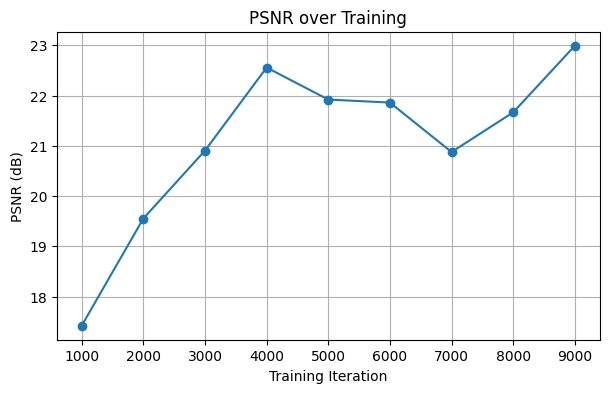

In [ ]:
steps = list(range(1000, 10000, 1000))

plt.figure(figsize=(7, 4))
plt.plot(steps, psnr_vals, marker="o")
plt.xlabel("Training Iteration")
plt.ylabel("PSNR (dB)")
plt.title("PSNR over Training")
plt.grid(True)
plt.show()

In [ ]:
@torch.no_grad()
def render_image(model, pose, H, W, focal, device, near=2.0, far=6.0,
                 num_samples=128, chunk_size=4096, scene_bound=4.0):
    model.eval()

    # Generate all rays for this camera
    rays_o, rays_d = get_ray(H, W, pose, focal)  # should return rays_o, rays_d
    rays_o = rays_o.reshape(-1, 3).to(device)   # [H*W, 3]
    rays_d = rays_d.reshape(-1, 3).to(device)   # [H*W, 3]

    rendered_chunks = []

    for start in range(0, rays_o.shape[0], chunk_size):
        end = start + chunk_size

        batch_rays_o = rays_o[start:end]
        batch_rays_d = rays_d[start:end]

        # Sample points along rays
        points, t_vals = sample_points_uniform(
            batch_rays_o,
            batch_rays_d,
            near=near,
            far=far,
            num_samples=num_samples
        )

        B, S, _ = points.shape
        points_flat = points.reshape(B * S, 3)

        # Normalize points before hash-grid encoder
        points_flat = (points_flat + scene_bound) / (2 * scene_bound)
        points_flat = points_flat.clamp(0.0, 1.0)

        # Model forward
        raw = model(points_flat)          # [B*S, 4]
        raw = raw.reshape(B, S, 4)

        rgb = torch.sigmoid(raw[..., :3])         # [B, S, 3]
        sigma = F.softplus(raw[..., 3])           # [B, S]

        # Volume render
        pred_rgb, _ = volume_renderer(rgb, sigma, t_vals)

        rendered_chunks.append(pred_rgb)

    pred = torch.cat(rendered_chunks, dim=0)      # [H*W, 3]
    pred_img = pred.reshape(H, W, 3)

    return pred_img.cpu()

In [ ]:
img_i = 2

test_imgs, test_poses, H, W, focal = load_blender_split("/content/data/nerf_synthetic/lego", split = 'test')
pose = test_poses[img_i].to(device)
gt_img = test_imgs[img_i].cpu()

pred_img = render_image(
    model=model,
    pose=pose,
    H=H,
    W=W,
    focal=focal,
    device=device,
    near=2.0,
    far=6.0,
    num_samples=128,
    chunk_size=4096
)

/tmp/ipykernel_3083/1137878810.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path).astype(np.float32) / 255.0


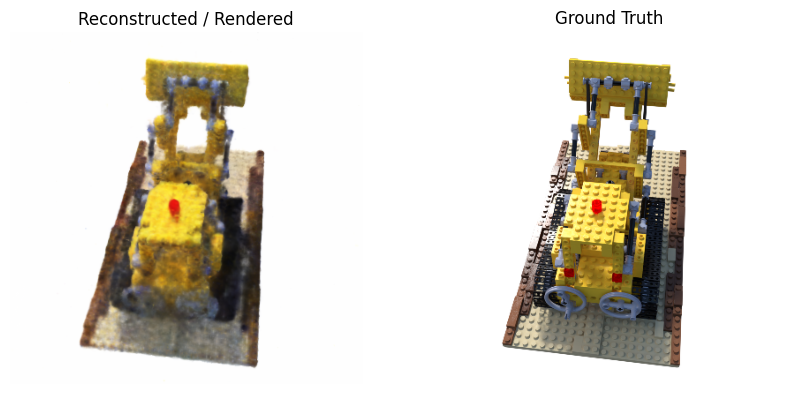

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(pred_img.clamp(0, 1))
plt.title("Reconstructed / Rendered")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gt_img.clamp(0, 1))
plt.title("Ground Truth")
plt.axis("off")

plt.show()

In [ ]:
@torch.no_grad()
def export_density_point_cloud(
    model,
    scene_bound=4.0,
    resolution=128,
    density_percentile_keep=90,
    color_percentile_low=5,
    color_percentile_high=99,
    chunk_size=65536,
    device="cuda",
    out_path="/content/nerf_density_points.ply"
):
    model.eval()

    # 1. Create 3D grid points in world coordinates
    lin = torch.linspace(-scene_bound, scene_bound, resolution, device=device)
    x, y, z = torch.meshgrid(lin, lin, lin, indexing="ij")
    points = torch.stack([x, y, z], dim=-1).reshape(-1, 3)  # [R^3, 3]

    densities = []

    # 2. Query density in chunks
    for start in range(0, points.shape[0], chunk_size):
        pts = points[start:start + chunk_size]

        # Normalize points if your hash grid expects [0, 1]^3
        pts_norm = (pts + scene_bound) / (2 * scene_bound)
        pts_norm = pts_norm.clamp(0.0, 1.0)

        raw = model(pts_norm)
        sigma = F.softplus(raw[..., 3])

        densities.append(sigma.cpu())

    densities = torch.cat(densities, dim=0).numpy()
    points_np = points.cpu().numpy()

    # 3. Keep only relatively dense points
    keep_threshold = np.percentile(densities, density_percentile_keep)
    keep = densities > keep_threshold

    points_keep = points_np[keep]
    density_keep = densities[keep]

    print("Kept points:", points_keep.shape[0])
    print("Density range kept:", density_keep.min(), density_keep.max())

    # 4. Normalize density for coloring
    low = np.percentile(density_keep, color_percentile_low)
    high = np.percentile(density_keep, color_percentile_high)

    density_norm = (density_keep - low) / (high - low + 1e-8)
    density_norm = np.clip(density_norm, 0.0, 1.0)

    # 5. Apply heatmap colormap
    cmap = plt.get_cmap("inferno")
    colors = cmap(density_norm)[:, :3]
    colors_uint8 = (colors * 255).astype(np.uint8)

    # 6. Export as point cloud
    cloud = trimesh.points.PointCloud(
        vertices=points_keep,
        colors=colors_uint8
    )

    cloud.export(out_path)

    return points_keep, density_keep, colors_uint8


In [ ]:
points_keep, density_keep, colors_uint8 = export_density_point_cloud(
    model,
    scene_bound=4.0,
    resolution=128,
    density_percentile_keep=90,
    device=device,
    out_path="/content/nerf_density_points.ply"
)

Kept points: 209716
Density range kept: 0.3028197 180.9365
